In [1]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows',None)
pd.set_option('display.max_column',None)
pd.set_option('display.width',None)

## Global Energy Price Dataset

### 1. Data Cleaning and Transformation

In [84]:
#Read the dataset

df=pd.read_excel('Data set (2).xlsx')

In [3]:
#First Five rows

df.head()

,Date,Coal_RB_4800_FOB_London_Close_USD,Coal_RB_5500_FOB_London_Close_USD,Coal_RB_5700_FOB_London_Close_USD,Coal_RB_6000_FOB_CurrentWeek_Avg_USD,Coal_India_5500_CFR_London_Close_USD,Price_WTI,Price_Brent_Oil,Price_Dubai_Brent_Oil,Price_ExxonMobil,Price_Shenhua,Price_All_Share,Price_Mining,Price_LNG_Japan_Korea_Marker_PLATTS,Price_ZAR_USD,Price_Natural_Gas,Price_ICE,Price_Dutch_TTF,Price_Indian_en_exg_rate
0,2020-04-02,41.00,53.22,64.7,97.56,60.50,25.32,29.94,26.16,40.40,14.58,45060.69,35562.37,2.860,0.05411,1.552,81.14,6.935,NaN
1,2020-04-03,40.34,52.36,63.1,70.57,62.03,28.34,34.11,29.39,39.21,14.14,44598.70,35258.30,2.845,0.05245,1.621,80.99,6.920,45.02
2,2020-04-06,40.34,52.36,63.1,70.57,62.03,26.08,33.05,27.45,40.47,14.26,46240.35,37032.31,2.850,0.05351,1.731,84.43,7.285,NaN
3,2020-04-07,40.34,52.36,63.1,70.57,62.03,23.63,31.87,26.00,41.24,14.46,47496.72,38362.12,2.805,0.05457,1.852,82.30,7.285,48.32
4,2020-04-08,40.34,52.36,63.1,70.57,62.03,25.09,32.84,26.16,43.85,14.24,46689.90,37469.17,2.810,0.05493,1.783,85.34,7.260,45.75


In [4]:
#Data Size
df.shape

(1107, 19)

##### Dataset Contains 1107 Rows and 19 Columns.

In [5]:
#Unique Column
df.columns

Index(['Date', 'Coal_RB_4800_FOB_London_Close_USD',
       'Coal_RB_5500_FOB_London_Close_USD',
       'Coal_RB_5700_FOB_London_Close_USD',
       'Coal_RB_6000_FOB_CurrentWeek_Avg_USD',
       'Coal_India_5500_CFR_London_Close_USD', 'Price_WTI', 'Price_Brent_Oil',
       'Price_Dubai_Brent_Oil', 'Price_ExxonMobil', 'Price_Shenhua',
       'Price_All_Share', 'Price_Mining',
       'Price_LNG_Japan_Korea_Marker_PLATTS', 'Price_ZAR_USD',
       'Price_Natural_Gas', 'Price_ICE', 'Price_Dutch_TTF',
       'Price_Indian_en_exg_rate'],
      dtype='object')

In [6]:
#Data Summary 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  1107 non-null   datetime64[ns]
 1   Coal_RB_4800_FOB_London_Close_USD     1068 non-null   float64       
 2   Coal_RB_5500_FOB_London_Close_USD     1068 non-null   float64       
 3   Coal_RB_5700_FOB_London_Close_USD     1068 non-null   float64       
 4   Coal_RB_6000_FOB_CurrentWeek_Avg_USD  1084 non-null   float64       
 5   Coal_India_5500_CFR_London_Close_USD  1068 non-null   float64       
 6   Price_WTI                             1099 non-null   float64       
 7   Price_Brent_Oil                       1096 non-null   float64       
 8   Price_Dubai_Brent_Oil                 1067 non-null   float64       
 9   Price_ExxonMobil                      1067 non-null   float64       
 10  

In [7]:
#checking nulls

df.isnull().any()

Date                                    False
Coal_RB_4800_FOB_London_Close_USD        True
Coal_RB_5500_FOB_London_Close_USD        True
Coal_RB_5700_FOB_London_Close_USD        True
Coal_RB_6000_FOB_CurrentWeek_Avg_USD     True
Coal_India_5500_CFR_London_Close_USD     True
Price_WTI                                True
Price_Brent_Oil                          True
Price_Dubai_Brent_Oil                    True
Price_ExxonMobil                         True
Price_Shenhua                            True
Price_All_Share                          True
Price_Mining                             True
Price_LNG_Japan_Korea_Marker_PLATTS      True
Price_ZAR_USD                           False
Price_Natural_Gas                        True
Price_ICE                                True
Price_Dutch_TTF                          True
Price_Indian_en_exg_rate                 True
dtype: bool

In [8]:
#Checking Null Count in each column

df.isnull().sum()


Date                                     0
Coal_RB_4800_FOB_London_Close_USD       39
Coal_RB_5500_FOB_London_Close_USD       39
Coal_RB_5700_FOB_London_Close_USD       39
Coal_RB_6000_FOB_CurrentWeek_Avg_USD    23
Coal_India_5500_CFR_London_Close_USD    39
Price_WTI                                8
Price_Brent_Oil                         11
Price_Dubai_Brent_Oil                   40
Price_ExxonMobil                        40
Price_Shenhua                           65
Price_All_Share                         49
Price_Mining                            49
Price_LNG_Japan_Korea_Marker_PLATTS     41
Price_ZAR_USD                            0
Price_Natural_Gas                        8
Price_ICE                               40
Price_Dutch_TTF                         31
Price_Indian_en_exg_rate                60
dtype: int64

In [9]:
#Percent of total null counts in each column

(df.isnull().sum()/len(df))*100

Date                                    0.000000
Coal_RB_4800_FOB_London_Close_USD       3.523035
Coal_RB_5500_FOB_London_Close_USD       3.523035
Coal_RB_5700_FOB_London_Close_USD       3.523035
Coal_RB_6000_FOB_CurrentWeek_Avg_USD    2.077687
Coal_India_5500_CFR_London_Close_USD    3.523035
Price_WTI                               0.722674
Price_Brent_Oil                         0.993677
Price_Dubai_Brent_Oil                   3.613369
Price_ExxonMobil                        3.613369
Price_Shenhua                           5.871725
Price_All_Share                         4.426378
Price_Mining                            4.426378
Price_LNG_Japan_Korea_Marker_PLATTS     3.703704
Price_ZAR_USD                           0.000000
Price_Natural_Gas                       0.722674
Price_ICE                               3.613369
Price_Dutch_TTF                         2.800361
Price_Indian_en_exg_rate                5.420054
dtype: float64

In [10]:
#Total nulls in the dataset

df.isnull().sum().sum()


np.int64(621)

##### Total null counts in the dataset - 621

In [11]:
#Total percent of null counts in the dataset

(df.isnull().sum().sum()/len(df))*100

np.float64(56.09756097560976)

                           
##### 56% of the dataset contains null values

In [12]:
#Duplicate values in the dataset
df[df.duplicated()]

,Date,Coal_RB_4800_FOB_London_Close_USD,Coal_RB_5500_FOB_London_Close_USD,Coal_RB_5700_FOB_London_Close_USD,Coal_RB_6000_FOB_CurrentWeek_Avg_USD,Coal_India_5500_CFR_London_Close_USD,Price_WTI,Price_Brent_Oil,Price_Dubai_Brent_Oil,Price_ExxonMobil,Price_Shenhua,Price_All_Share,Price_Mining,Price_LNG_Japan_Korea_Marker_PLATTS,Price_ZAR_USD,Price_Natural_Gas,Price_ICE,Price_Dutch_TTF,Price_Indian_en_exg_rate


In [13]:
#Duplicates values count 

df.duplicated().sum()

np.int64(0)

##### No duplicate values in the dataset

### 2. Handing Missing values in the dataset

In [14]:
#copy dataset
df2=df.copy()

In [15]:
df2.dtypes

Date                                    datetime64[ns]
Coal_RB_4800_FOB_London_Close_USD              float64
Coal_RB_5500_FOB_London_Close_USD              float64
Coal_RB_5700_FOB_London_Close_USD              float64
Coal_RB_6000_FOB_CurrentWeek_Avg_USD           float64
Coal_India_5500_CFR_London_Close_USD           float64
Price_WTI                                      float64
Price_Brent_Oil                                float64
Price_Dubai_Brent_Oil                          float64
Price_ExxonMobil                               float64
Price_Shenhua                                  float64
Price_All_Share                                float64
Price_Mining                                   float64
Price_LNG_Japan_Korea_Marker_PLATTS            float64
Price_ZAR_USD                                  float64
Price_Natural_Gas                              float64
Price_ICE                                      float64
Price_Dutch_TTF                                float64
Price_Indi

In [16]:
df2.isnull().sum()

Date                                     0
Coal_RB_4800_FOB_London_Close_USD       39
Coal_RB_5500_FOB_London_Close_USD       39
Coal_RB_5700_FOB_London_Close_USD       39
Coal_RB_6000_FOB_CurrentWeek_Avg_USD    23
Coal_India_5500_CFR_London_Close_USD    39
Price_WTI                                8
Price_Brent_Oil                         11
Price_Dubai_Brent_Oil                   40
Price_ExxonMobil                        40
Price_Shenhua                           65
Price_All_Share                         49
Price_Mining                            49
Price_LNG_Japan_Korea_Marker_PLATTS     41
Price_ZAR_USD                            0
Price_Natural_Gas                        8
Price_ICE                               40
Price_Dutch_TTF                         31
Price_Indian_en_exg_rate                60
dtype: int64

In [17]:
#Statistical summary of null contain dataset:
df2.describe()

,Date,Coal_RB_4800_FOB_London_Close_USD,Coal_RB_5500_FOB_London_Close_USD,Coal_RB_5700_FOB_London_Close_USD,Coal_RB_6000_FOB_CurrentWeek_Avg_USD,Coal_India_5500_CFR_London_Close_USD,Price_WTI,Price_Brent_Oil,Price_Dubai_Brent_Oil,Price_ExxonMobil,Price_Shenhua,Price_All_Share,Price_Mining,Price_LNG_Japan_Korea_Marker_PLATTS,Price_ZAR_USD,Price_Natural_Gas,Price_ICE,Price_Dutch_TTF,Price_Indian_en_exg_rate
count,1107,1068.000000,1068.000000,1068.000000,1084.000000,1068.000000,1099.000000,1096.000000,1067.000000,1067.000000,1042.000000,1058.000000,1058.000000,1066.000000,1107.000000,1099.000000,1067.000000,1076.000000,1047.000000
mean,2022-05-16 14:22:26.341463296,87.953184,113.353155,134.971807,144.351494,123.759710,72.345469,76.283020,74.752493,80.871012,21.274702,68736.904811,52972.178374,17.622529,0.059943,3.697999,112.756111,57.384856,141.616027
min,2020-04-02 00:00:00,26.750000,34.560000,44.690000,44.530000,41.810000,-37.630000,19.330000,19.070000,31.570000,12.060000,44598.700000,35258.300000,1.995000,0.050470,1.482000,80.990000,3.510000,45.020000
25%,2021-04-24 12:00:00,50.370000,67.880000,83.400000,92.420000,81.990000,64.225000,67.457500,65.480000,56.035000,15.275000,65639.547500,47161.832500,8.851250,0.054290,2.458500,101.900000,22.406250,119.065000
50%,2022-05-17 00:00:00,76.190000,95.800000,108.910000,115.270000,111.200000,75.670000,79.960000,78.790000,86.410000,22.325000,70089.085000,53270.245000,12.902500,0.058720,2.863000,111.960000,35.838500,140.900000
75%,2023-06-07 12:00:00,104.180000,129.260000,155.600000,172.550000,150.040000,83.180000,87.450000,87.275000,106.480000,24.937500,74775.762500,57707.622500,25.993750,0.065640,4.710500,122.620000,83.962500,162.350000
max,2024-06-28 00:00:00,301.090000,360.240000,412.350000,428.220000,312.890000,123.700000,127.980000,122.530000,122.200000,40.300000,80791.360000,75185.760000,69.955000,0.074350,9.647000,139.430000,339.195000,295.250000
std,NaN,47.303473,63.105405,77.472391,83.500186,56.502138,20.605415,20.723186,20.505811,27.771904,6.136281,7928.639789,7037.617925,12.716663,0.006068,1.921176,13.729638,53.328953,54.147294


##### Replacing null values in each column with mean values of that column.

In [18]:
#Replacing null values in every null column with mean of the that column

df2['Coal_RB_4800_FOB_London_Close_USD'].fillna(df2['Coal_RB_4800_FOB_London_Close_USD'].mean(),inplace = True)
df2['Coal_RB_5500_FOB_London_Close_USD'].fillna(df2['Coal_RB_5500_FOB_London_Close_USD'].mean(),inplace = True)
df2['Coal_RB_5700_FOB_London_Close_USD'].fillna(df2['Coal_RB_5700_FOB_London_Close_USD'].mean(),inplace = True)
df2['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].fillna(df2['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].mean(),inplace = True)
df2['Coal_India_5500_CFR_London_Close_USD'].fillna(df['Coal_India_5500_CFR_London_Close_USD'].mean(),inplace = True)
df2['Price_WTI'].fillna(df2['Price_WTI'].mean(),inplace = True)
df2['Price_Brent_Oil'].fillna(df2['Price_Brent_Oil'].mean(),inplace = True)
df2['Price_Dubai_Brent_Oil'].fillna(df2['Price_Dubai_Brent_Oil'].mean(),inplace = True)
df2['Price_ExxonMobil'].fillna(df2['Price_ExxonMobil'].mean(),inplace = True)
df2['Price_Shenhua'].fillna(df2['Price_Shenhua'].mean(),inplace = True)
df2['Price_All_Share'].fillna(df2['Price_All_Share'].mean(),inplace = True)
df2['Price_Mining'].fillna(df2['Price_Mining'].mean(),inplace = True)
df2['Price_LNG_Japan_Korea_Marker_PLATTS'].fillna(df2['Price_LNG_Japan_Korea_Marker_PLATTS'].mean(),inplace = True)
df2['Price_Natural_Gas'].fillna(df2['Price_Natural_Gas'].mean(),inplace = True)
df2['Price_ICE'].fillna(df2['Price_ICE'].mean(),inplace = True)
df2['Price_Dutch_TTF'].fillna(df2['Price_Dutch_TTF'].mean(),inplace = True)
df2['Price_Indian_en_exg_rate'].fillna(df2['Price_Indian_en_exg_rate'].mean(),inplace = True)

C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_29832\1627943074.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Coal_RB_4800_FOB_London_Close_USD'].fillna(df2['Coal_RB_4800_FOB_London_Close_USD'].mean(),inplace = True)
C:\Users\sujal_sahu\AppData\Local\Temp\ipykernel_29832\1627943074.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate

In [19]:
df2.isnull().sum()

Date                                    0
Coal_RB_4800_FOB_London_Close_USD       0
Coal_RB_5500_FOB_London_Close_USD       0
Coal_RB_5700_FOB_London_Close_USD       0
Coal_RB_6000_FOB_CurrentWeek_Avg_USD    0
Coal_India_5500_CFR_London_Close_USD    0
Price_WTI                               0
Price_Brent_Oil                         0
Price_Dubai_Brent_Oil                   0
Price_ExxonMobil                        0
Price_Shenhua                           0
Price_All_Share                         0
Price_Mining                            0
Price_LNG_Japan_Korea_Marker_PLATTS     0
Price_ZAR_USD                           0
Price_Natural_Gas                       0
Price_ICE                               0
Price_Dutch_TTF                         0
Price_Indian_en_exg_rate                0
dtype: int64

In [20]:
#Extract year, month, day from Date Feature in the dataset:
df2['Year'],df2['Month'],df2['Day']=df2['Date'].dt.year,df2['Date'].dt.month,df2['Date'].dt.day

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  1107 non-null   datetime64[ns]
 1   Coal_RB_4800_FOB_London_Close_USD     1107 non-null   float64       
 2   Coal_RB_5500_FOB_London_Close_USD     1107 non-null   float64       
 3   Coal_RB_5700_FOB_London_Close_USD     1107 non-null   float64       
 4   Coal_RB_6000_FOB_CurrentWeek_Avg_USD  1107 non-null   float64       
 5   Coal_India_5500_CFR_London_Close_USD  1107 non-null   float64       
 6   Price_WTI                             1107 non-null   float64       
 7   Price_Brent_Oil                       1107 non-null   float64       
 8   Price_Dubai_Brent_Oil                 1107 non-null   float64       
 9   Price_ExxonMobil                      1107 non-null   float64       
 10  

In [22]:
#Statistical Summary of cleaned dataset
df2.describe()

,Date,Coal_RB_4800_FOB_London_Close_USD,Coal_RB_5500_FOB_London_Close_USD,Coal_RB_5700_FOB_London_Close_USD,Coal_RB_6000_FOB_CurrentWeek_Avg_USD,Coal_India_5500_CFR_London_Close_USD,Price_WTI,Price_Brent_Oil,Price_Dubai_Brent_Oil,Price_ExxonMobil,Price_Shenhua,Price_All_Share,Price_Mining,Price_LNG_Japan_Korea_Marker_PLATTS,Price_ZAR_USD,Price_Natural_Gas,Price_ICE,Price_Dutch_TTF,Price_Indian_en_exg_rate,Year,Month,Day
count,1107,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000
mean,2022-05-16 14:22:26.341463296,87.953184,113.353155,134.971807,144.351494,123.759710,72.345469,76.283020,74.752493,80.871012,21.274702,68736.904811,52972.178374,17.622529,0.059943,3.697999,112.756111,57.384856,141.616027,2021.879855,6.440831,15.715447
min,2020-04-02 00:00:00,26.750000,34.560000,44.690000,44.530000,41.810000,-37.630000,19.330000,19.070000,31.570000,12.060000,44598.700000,35258.300000,1.995000,0.050470,1.482000,80.990000,3.510000,45.020000,2020.000000,1.000000,1.000000
25%,2021-04-24 12:00:00,52.560000,72.390000,87.650000,92.820000,84.030000,64.545000,67.950000,66.270000,56.510000,15.740000,65850.295000,47369.245000,9.117500,0.054290,2.472000,102.375000,23.645000,122.200000,2021.000000,4.000000,8.000000
50%,2022-05-17 00:00:00,77.810000,97.280000,110.940000,115.630000,111.680000,75.570000,79.670000,78.180000,84.810000,21.850000,69401.950000,52972.178374,13.335000,0.058720,2.879000,112.420000,36.780000,141.616027,2022.000000,6.000000,16.000000
75%,2023-06-07 12:00:00,101.100000,126.640000,150.350000,166.490000,146.980000,83.050000,87.395000,86.435000,106.065000,24.775000,74545.810000,57377.885000,25.237500,0.065640,4.699000,121.090000,82.512500,159.925000,2023.000000,9.000000,23.000000
max,2024-06-28 00:00:00,301.090000,360.240000,412.350000,428.220000,312.890000,123.700000,127.980000,122.530000,122.200000,40.300000,80791.360000,75185.760000,69.955000,0.074350,9.647000,139.430000,339.195000,295.250000,2024.000000,12.000000,31.000000
std,NaN,46.461976,61.982802,76.094209,82.627404,55.497003,20.530757,20.619874,20.131586,27.265075,5.953235,7751.015722,6879.955280,12.478731,0.006068,1.914215,13.479077,52.576264,52.658082,1.278922,3.372701,8.795824


In [23]:
df2.to_excel('Clean Data set.xlsx',index=False)

# Exploratory Data Analysis

In [24]:
df = pd.read_excel('Clean Data set.xlsx')

In [25]:
df.describe()

,Date,Coal_RB_4800_FOB_London_Close_USD,Coal_RB_5500_FOB_London_Close_USD,Coal_RB_5700_FOB_London_Close_USD,Coal_RB_6000_FOB_CurrentWeek_Avg_USD,Coal_India_5500_CFR_London_Close_USD,Price_WTI,Price_Brent_Oil,Price_Dubai_Brent_Oil,Price_ExxonMobil,Price_Shenhua,Price_All_Share,Price_Mining,Price_LNG_Japan_Korea_Marker_PLATTS,Price_ZAR_USD,Price_Natural_Gas,Price_ICE,Price_Dutch_TTF,Price_Indian_en_exg_rate,Year,Month,Day
count,1107,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000,1107.000000
mean,2022-05-16 14:22:26.341463296,87.953184,113.353155,134.971807,144.351494,123.759710,72.345469,76.283020,74.752493,80.871012,21.274702,68736.904811,52972.178374,17.622529,0.059943,3.697999,112.756111,57.384856,141.616027,2021.879855,6.440831,15.715447
min,2020-04-02 00:00:00,26.750000,34.560000,44.690000,44.530000,41.810000,-37.630000,19.330000,19.070000,31.570000,12.060000,44598.700000,35258.300000,1.995000,0.050470,1.482000,80.990000,3.510000,45.020000,2020.000000,1.000000,1.000000
25%,2021-04-24 12:00:00,52.560000,72.390000,87.650000,92.820000,84.030000,64.545000,67.950000,66.270000,56.510000,15.740000,65850.295000,47369.245000,9.117500,0.054290,2.472000,102.375000,23.645000,122.200000,2021.000000,4.000000,8.000000
50%,2022-05-17 00:00:00,77.810000,97.280000,110.940000,115.630000,111.680000,75.570000,79.670000,78.180000,84.810000,21.850000,69401.950000,52972.178374,13.335000,0.058720,2.879000,112.420000,36.780000,141.616027,2022.000000,6.000000,16.000000
75%,2023-06-07 12:00:00,101.100000,126.640000,150.350000,166.490000,146.980000,83.050000,87.395000,86.435000,106.065000,24.775000,74545.810000,57377.885000,25.237500,0.065640,4.699000,121.090000,82.512500,159.925000,2023.000000,9.000000,23.000000
max,2024-06-28 00:00:00,301.090000,360.240000,412.350000,428.220000,312.890000,123.700000,127.980000,122.530000,122.200000,40.300000,80791.360000,75185.760000,69.955000,0.074350,9.647000,139.430000,339.195000,295.250000,2024.000000,12.000000,31.000000
std,NaN,46.461976,61.982802,76.094209,82.627404,55.497003,20.530757,20.619874,20.131586,27.265075,5.953235,7751.015722,6879.955280,12.478731,0.006068,1.914215,13.479077,52.576264,52.658082,1.278922,3.372701,8.795824


### Average price of global oil benchmarks across US, Europe and middle east

Average closing price of US benchmark oil (Western Texas Internmediate) is 72.34

Average closing price of european oil benchmark is 76.28

Average closing price of middle east benchmark oil is 74.57

#### Conclusion : European oil benchmark leading the average price of oil.

## Average price of different coal grades in USD

1. Average closing price of coal grade 4800 is 87.95 in USD.

2. Average closing price of coal grade 5500 is 133.35 in USD.

3. Average closing price of coal grade 5700 is 134.97 in USD.

4. Average closing price of coal grade 6000 current week is 144.35 in USD.

## Average Stock price and indexes across global market.

1. Avrage closing stock price of exxonmobil index is 80.87

2. Average closing stock price of shenuha index is 21.2

3. average closing index value of all share index is 68736.90

#### Conclusion : Exxonmobil stocks and all share index value leading the market.



In [26]:
df.columns

Index(['Date', 'Coal_RB_4800_FOB_London_Close_USD',
       'Coal_RB_5500_FOB_London_Close_USD',
       'Coal_RB_5700_FOB_London_Close_USD',
       'Coal_RB_6000_FOB_CurrentWeek_Avg_USD',
       'Coal_India_5500_CFR_London_Close_USD', 'Price_WTI', 'Price_Brent_Oil',
       'Price_Dubai_Brent_Oil', 'Price_ExxonMobil', 'Price_Shenhua',
       'Price_All_Share', 'Price_Mining',
       'Price_LNG_Japan_Korea_Marker_PLATTS', 'Price_ZAR_USD',
       'Price_Natural_Gas', 'Price_ICE', 'Price_Dutch_TTF',
       'Price_Indian_en_exg_rate', 'Year', 'Month', 'Day'],
      dtype='object')

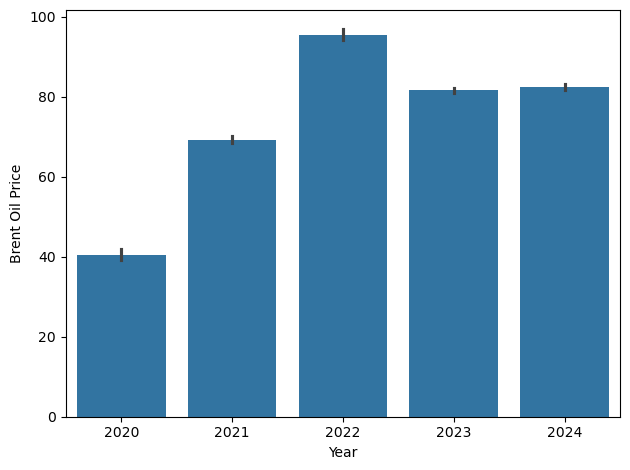

In [27]:
#Analyzing Brent Oil price over time:

sns.barplot(x=df['Year'], y='Price_Dubai_Brent_Oil',data=df)
plt.xlabel('Year')
plt.ylabel('Brent Oil Price')
plt.tight_layout()
plt.show()

In [28]:
#Price of brent oil in each year:

df.groupby('Year')['Price_Dubai_Brent_Oil'].sum().sort_values(ascending=False)

Year
2022    24821.612437
2023    21218.834930
2021    18063.932437
2024    10713.614958
2020     7933.014958
Name: Price_Dubai_Brent_Oil, dtype: float64

##### Conclusion : Brent oil prices shows a consistent upward trend in year 2022 around 24821.61 in USD, indicating increasing global demand or supply in a year.

## Representing Correlation between different features of a dataset.

<Axes: >

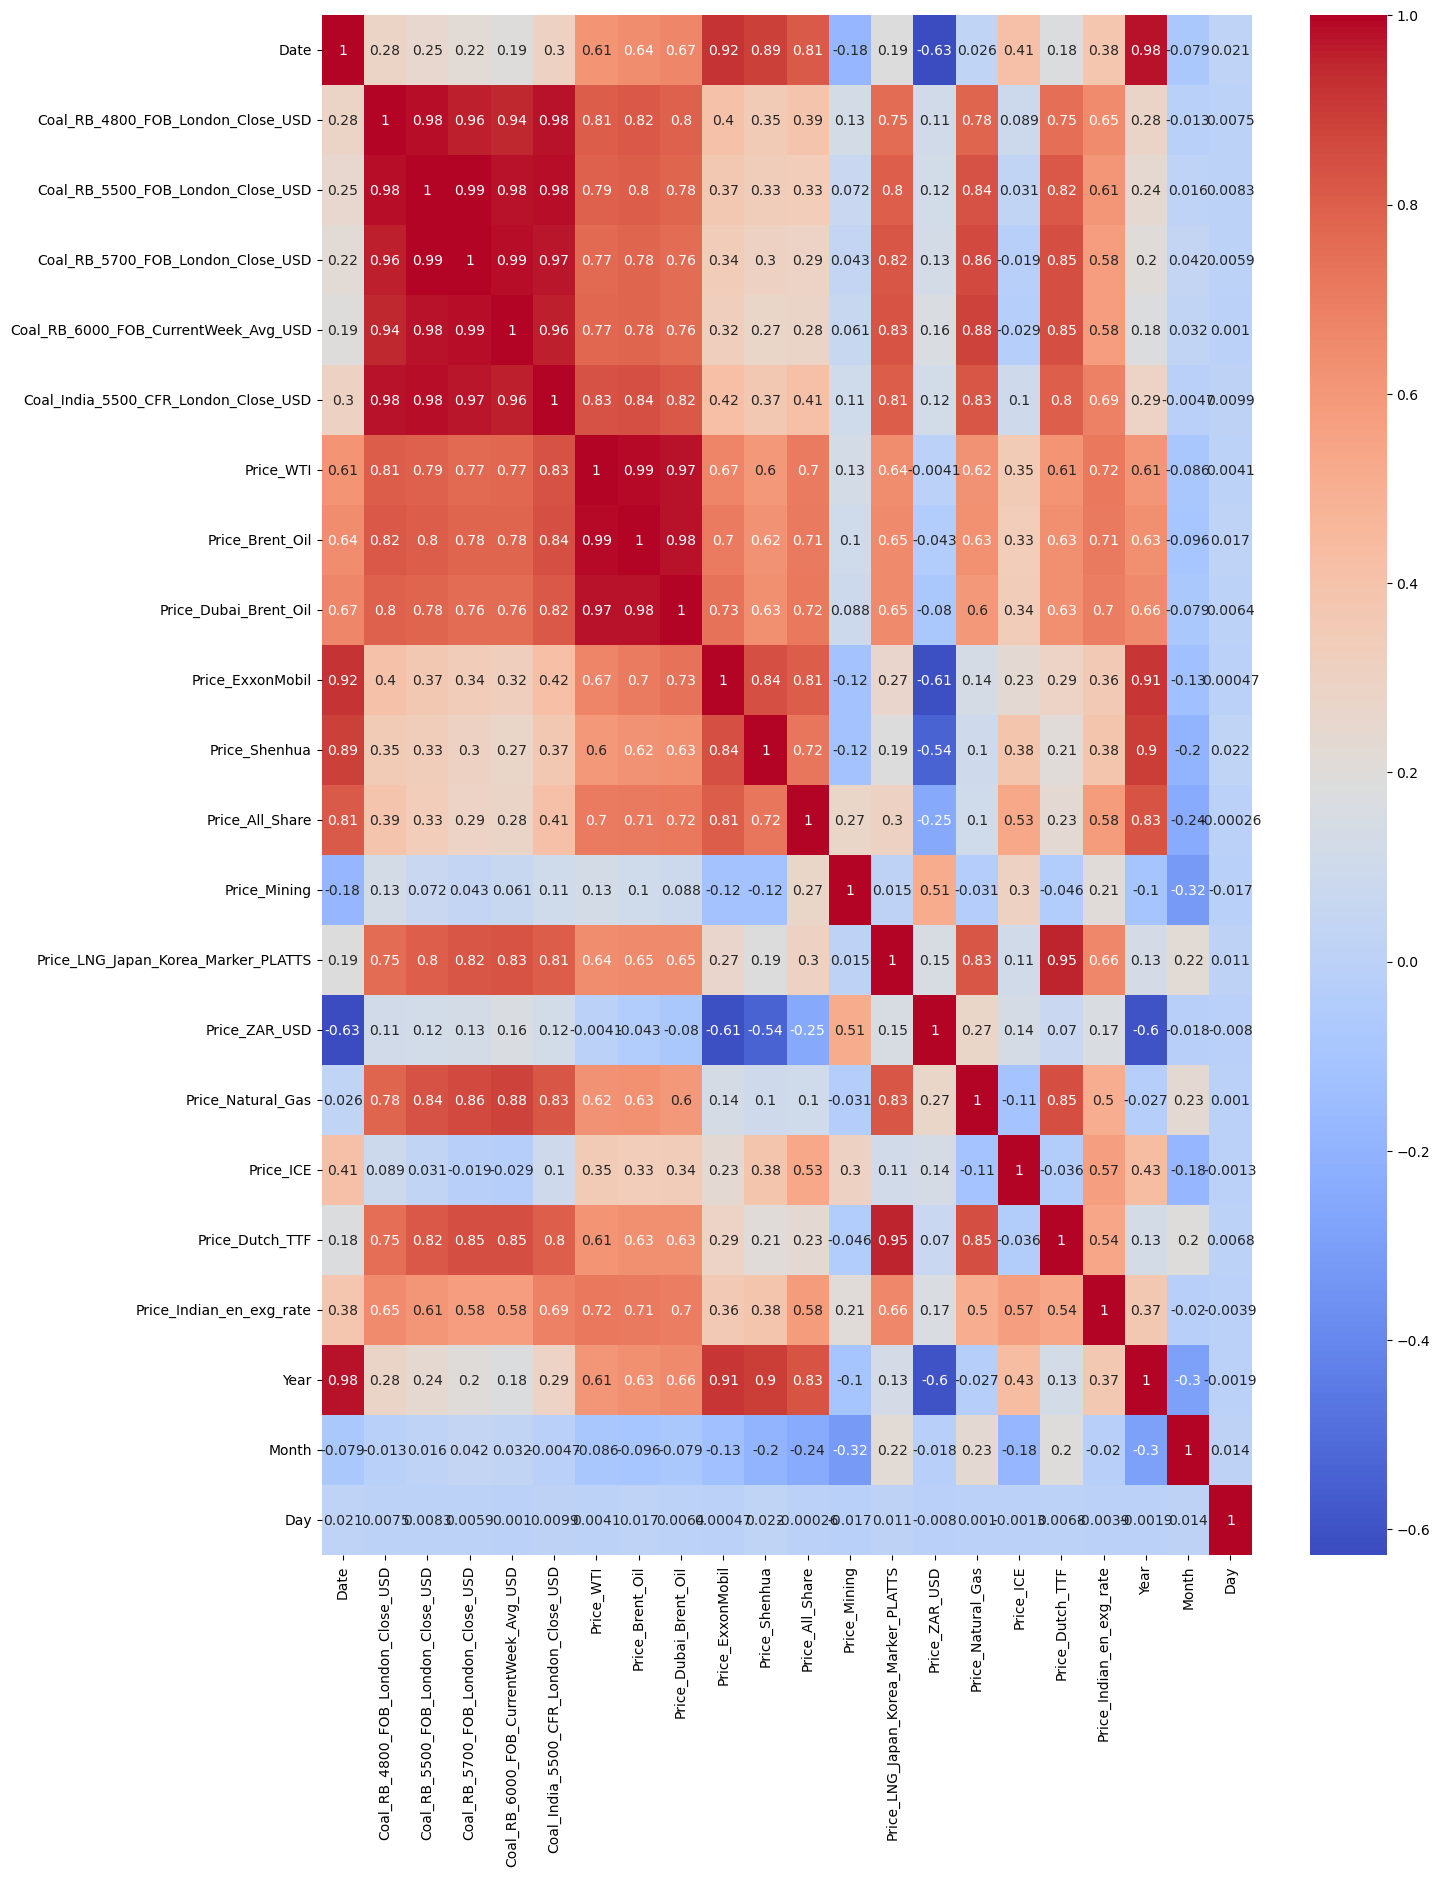

In [29]:
# Correlation between features of global energy dataset

relation = df.corr()
plt.figure(figsize=(15,20))
sns.heatmap(relation,annot=True,cmap='coolwarm')


#### Conclusion: Shows positive, negative and neutral relationship between different features of a dataset.

##### 1. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Coal_RB_4800_FOB_London_Close_USD.

In [30]:
#Measure of central tendency 

Mean_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].mean()
Median_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].median()
Mode_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].mode()[0]

print('Mean of Coal_RB_4800_FOB_London_Close_USD is:',Mean_coal_4800)
print('Median of Coal_RB_4800_FOB_London_Close_USD is:',Median_coal_4800)
print('Mode of Coal_RB_4800_FOB_London_Close_USD is:',Mode_coal_4800)

Mean of Coal_RB_4800_FOB_London_Close_USD is: 87.95318352059925
Median of Coal_RB_4800_FOB_London_Close_USD is: 77.81
Mode of Coal_RB_4800_FOB_London_Close_USD is: 87.95318352059924


In [31]:
#Measure of dispersion

variance_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].var()
std_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].std()
Range_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].max()-df['Coal_RB_4800_FOB_London_Close_USD'].min()

print('Variance of Coal_RB_4800_FOB_London_Close_USD is: ', variance_coal_4800)
print('Standard deviation of Coal_RB_4800_FOB_London_Close_USD is: ', std_coal_4800)
print('Range of Coal_RB_4800_FOB_London_Close_USD is: ', Range_coal_4800)


Variance of Coal_RB_4800_FOB_London_Close_USD is:  2158.7151992549902
Standard deviation of Coal_RB_4800_FOB_London_Close_USD is:  46.46197584320958
Range of Coal_RB_4800_FOB_London_Close_USD is:  274.34


In [32]:
#Skewness and Kurtosis

skewness_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].skew()
kurtosis_coal_4800 = df['Coal_RB_4800_FOB_London_Close_USD'].kurt()

print(df['Coal_RB_4800_FOB_London_Close_USD'].min())
print(df['Coal_RB_4800_FOB_London_Close_USD'].max())
print('Skewness of Coal_RB_4800_FOB_London_Close_USD is: ', skewness_coal_4800)
print('Kurtosis of Coal_RB_4800_FOB_London_Close_USD is: ', kurtosis_coal_4800)

26.75
301.09
Skewness of Coal_RB_4800_FOB_London_Close_USD is:  1.3365136207003154
Kurtosis of Coal_RB_4800_FOB_London_Close_USD is:  2.303051097909085


Conclusion: Coal_RB_4800_FOB_London_Close_USD has a mean of 87.95, median of 77.81, and mode of 87.95. Since the 
mean is higher than the median, this indicates that the distribution is right-skewed. The standard deviation is 46.4, showing the average deviation of values from the mean. The range (max - min) is high, indicating significant variability in coal prices. The skewness is greater than 1, suggesting the presence of extreme outliers. The kurtosis is 2.30, meaning it follows a leptokurtic distribution with high extreme values in the feature.

##### 2. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Coal_RB_5500_FOB_London_Close_USD.

In [33]:
#Measure of central tendency

Mean_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].mean()
Median_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].median()
Mode_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].mode()[0]

print('Mean of Coal_RB_5500_FOB_London_Close_USD is:',Mean_coal_5500)
print('Median of Coal_RB_5500_FOB_London_Close_USD is:',Median_coal_5500)
print('Mode of Coal_RB_5500_FOB_London_Close_USD is:',Mode_coal_5500)

Mean of Coal_RB_5500_FOB_London_Close_USD is: 113.35315543071161
Median of Coal_RB_5500_FOB_London_Close_USD is: 97.28
Mode of Coal_RB_5500_FOB_London_Close_USD is: 113.3531554307116


In [34]:
# Measure of dispersion

variance_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].var()
std_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].std()
range_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].max() - df['Coal_RB_5500_FOB_London_Close_USD'].min()

print('Variance of Coal_RB_5500_FOB_London_Close_USD is:', variance_coal_5500)
print('Standard deviation of Coal_RB_5500_FOB_London_Close_USD is:', std_coal_5500)
print('Range of Coal_RB_5500_FOB_London_Close_USD is:', range_coal_5500)

Variance of Coal_RB_5500_FOB_London_Close_USD is: 3841.8677387578477
Standard deviation of Coal_RB_5500_FOB_London_Close_USD is: 61.982801959558486
Range of Coal_RB_5500_FOB_London_Close_USD is: 325.68


In [35]:
#Skewness and Kurtosis

skewness_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].skew()
kurtosis_coal_5500 = df['Coal_RB_5500_FOB_London_Close_USD'].kurt()

print(df['Coal_RB_5500_FOB_London_Close_USD'].min())
print(df['Coal_RB_5500_FOB_London_Close_USD'].max())
print('Skewness of Coal_RB_5500_FOB_London_Close_USD is: ', skewness_coal_5500)
print('Kurtosis of Coal_RB_5500_FOB_London_Close_USD is: ', kurtosis_coal_5500)

34.56
360.24
Skewness of Coal_RB_5500_FOB_London_Close_USD is:  1.2832731016814816
Kurtosis of Coal_RB_5500_FOB_London_Close_USD is:  1.2779391183110795


 Conclusion: Feature Coal_RB_5500_FOB_London_Close_USD has mean, median and mode around 113.3, 97.2 and 113.3, indicating that mean is higher than median this shows the distribution of values is right skewed. Standard deviation is around 61.98 this shows the average difference between the values from mean. Range between min and max value of feature is 325.68, indicating variability in a feature. Skewness is 1.28 greater than 1, shows outliers present in the column. Kurtosis is 1.27, shows the distribution is leptocurtic.

##### 3. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Coal_RB_5700_FOB_London_Close_USD.

In [36]:
#Measure of central tendency

Mean_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].mean()
Median_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].median()
Mode_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].mode()[0]

print('Mean of Coal_RB_5700_FOB_London_Close_USD is:',Mean_coal_5700)
print('Median of Coal_RB_5700_FOB_London_Close_USD is: ',Median_coal_5700)
print('Mode of Coal_RB_5700_FOB_London_Close_USD is:',Mode_coal_5700)

Mean of Coal_RB_5700_FOB_London_Close_USD is: 134.97180711610488
Median of Coal_RB_5700_FOB_London_Close_USD is:  110.94
Mode of Coal_RB_5700_FOB_London_Close_USD is: 134.9718071161049


In [37]:
#Measure of dispersion

variance_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].var()
std_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].std()
Range_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].max()-df['Coal_RB_5700_FOB_London_Close_USD'].min()

print('Variance of Coal_RB_5700_FOB_London_Close_USD is: ', variance_coal_5700)
print('Standard deviation of Coal_RB_5700_FOB_London_Close_USD is: ', std_coal_5700)
print('Range of Coal_RB_5700_FOB_London_Close_USD is: ', Range_coal_5700)


Variance of Coal_RB_5700_FOB_London_Close_USD is:  5790.328623338392
Standard deviation of Coal_RB_5700_FOB_London_Close_USD is:  76.09420886860177
Range of Coal_RB_5700_FOB_London_Close_USD is:  367.66


In [38]:
#Skewness and Kurtosis

skewness_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].skew()
kurtosis_coal_5700 = df['Coal_RB_5700_FOB_London_Close_USD'].kurt()

print(df['Coal_RB_5700_FOB_London_Close_USD'].min())
print(df['Coal_RB_5700_FOB_London_Close_USD'].max())
print('Skewness of Coal_RB_5700_FOB_London_Close_USD is: ', skewness_coal_5700)
print('Kurtosis of Coal_RB_5700_FOB_London_Close_USD is: ', kurtosis_coal_5700)

44.69
412.35
Skewness of Coal_RB_5700_FOB_London_Close_USD is:  1.301122617217934
Kurtosis of Coal_RB_5700_FOB_London_Close_USD is:  0.9509559259663121


Conclusion: Coal_RB_5700_FOB_London_Close_USD has mean 134.97, Median 110.94, shows that mean is higher than median so the  distribution is right skewed. The standard deviation is 76.09, shows average deviation of values from mean. The range is high, shows that significant variability in coal price. The skewness is 1.30 means extreme outliers present in the column. The kurtosis is 0.95 mean it is less than 1 suggests a platykurtic distribution, meaning that the overall presence of extreme values is relatively low and the data is more evenly spread.

##### 4. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Coal_RB_6000_FOB_CurrentWeek_Avg_USD.

In [39]:
#Measure of central tendency

Mean_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].mean()
Median_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].median()
Mode_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].mode()[0]

print('Mean of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:',Mean_coal_6000)
print('Median of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:',Median_coal_6000)
print('Mode of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:',Mode_coal_6000)


Mean of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: 144.35149446494464
Median of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: 115.63
Mode of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: 144.3514944649446


In [40]:
#Measure of dispersion

variance_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].var()
std_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].std()
Range_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].max()-df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].min()

print('Variance of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: ', variance_coal_6000)
print('Standard deviation of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: ', std_coal_6000)
print('Range of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: ', Range_coal_6000)


Variance of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:  6827.287924935767
Standard deviation of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:  82.62740420063895
Range of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:  383.69000000000005


In [41]:
#Skewness and Kurtosis

skewness_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].skew()
kurtosis_coal_6000 = df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].kurt()

print(df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].min())
print(df['Coal_RB_6000_FOB_CurrentWeek_Avg_USD'].max())
print('Skewness of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: ', skewness_coal_6000)
print('Kurtosis of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is: ', kurtosis_coal_6000)

44.53
428.22
Skewness of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:  1.2828488163945504
Kurtosis of Coal_RB_6000_FOB_CurrentWeek_Avg_USD is:  0.7964989132692009


Conclusion: Coal_RB_6000_FOB_CurrentWeek_Avg_USD has a mean of 144.35 and a median of 115.63, which shows that the mean is higher than the median, indicating a right-skewed distribution. The standard deviation is 82.63, which shows that the values deviate quite a lot from the mean. The range is also high 383.69, indicating significant variability in coal prices. The skewness is 1.28, suggesting the presence of higher-value outliers in the data. The kurtosis is 0.79, which is less than 1 and suggests a platykurtic distribution, meaning that extreme values are not very frequent and the data is relatively more evenly spread.

##### 5. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Coal_India_5500_CFR_London_Close_USD.

In [42]:
#Measure of central tendency

Mean_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].mean()
Median_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].median()
Mode_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].mode()[0]

print('Mean of Coal_India_5500_CFR_London_Close_USD is:',Mean_coal_5500)
print('Median of Coal_India_5500_CFR_London_Close_USD is:',Median_coal_5500)
print('Mode of Coal_India_5500_CFR_London_Close_USD is:',Mode_coal_5500)

Mean of Coal_India_5500_CFR_London_Close_USD is: 123.75970973782772
Median of Coal_India_5500_CFR_London_Close_USD is: 111.68
Mode of Coal_India_5500_CFR_London_Close_USD is: 123.7597097378277


In [43]:
#Measure of dispersion

variance_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].var()
std_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].std()
Range_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].max()-df['Coal_India_5500_CFR_London_Close_USD'].min()

print('Variance of Coal_India_5500_CFR_London_Close_USD is: ', variance_coal_5500)
print('Standard deviation of Coal_India_5500_CFR_London_Close_USD is: ', std_coal_5500)
print('Range of Coal_India_5500_CFR_London_Close_USD is: ', Range_coal_5500)


Variance of Coal_India_5500_CFR_London_Close_USD is:  3079.9173200813757
Standard deviation of Coal_India_5500_CFR_London_Close_USD is:  55.49700280268634
Range of Coal_India_5500_CFR_London_Close_USD is:  271.08


In [44]:
#Skewness and Kurtosis

skewness_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].skew()
kurtosis_coal_5500 = df['Coal_India_5500_CFR_London_Close_USD'].kurt()

print(df['Coal_India_5500_CFR_London_Close_USD'].min())
print(df['Coal_India_5500_CFR_London_Close_USD'].max())
print('Skewness of Coal_India_5500_CFR_London_Close_USD is: ', skewness_coal_5500)
print('Kurtosis of Coal_India_5500_CFR_London_Close_USD is: ', kurtosis_coal_5500)

41.81
312.89
Skewness of Coal_India_5500_CFR_London_Close_USD is:  0.8778313634218226
Kurtosis of Coal_India_5500_CFR_London_Close_USD is:  0.2920821760178258


Conclusion: Coal_India_5500_CFR_London_Close_USD has mean 123.76, median 111.68, shows that mean is higher than median so the distribution is right skewed. The standard deviation is 55.50, shows average deviation of values from mean. The range is high 271.08, shows that significant variability in coal price. The skewness is 0.88 means moderate presence of higher value observations in the column. The kurtosis is 0.29 means it is less than 1 suggests a platykurtic distribution, meaning that the overall presence of extreme values is relatively low and the data is more evenly spread.

##### 6. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_WTI.

In [45]:
#Measure of central tendency

Mean_wti= df['Price_WTI'].mean()
Median_wti = df['Price_WTI'].median()
Mode_wti = df['Price_WTI'].mode()[0]

print('Mean of Price_WTI is:',Mean_wti)
print('Median of Price_WTI is:',Median_wti)
print('Mode of Price_WTI is:',Mode_wti)

Mean of Price_WTI is: 72.3454686078253
Median of Price_WTI is: 75.57
Mode of Price_WTI is: 72.3454686078253


In [46]:
#Measure of dispersion

variance_wti = df['Price_WTI'].var()
std_wti = df['Price_WTI'].std()
Range_wti = df['Price_WTI'].max() + df['Price_WTI'].min()

print('Variance of Price_WTI is: ', variance_wti)
print('Standard deviation of Price_WTI is: ', std_wti)
print('Range of Price_WTI is: ', Range_wti)


Variance of Price_WTI is:  421.5119933396632
Standard deviation of Price_WTI is:  20.53075725197839
Range of Price_WTI is:  86.07


In [47]:
#Skewness and Kurtosis

skewness_wti = df['Price_WTI'].skew()
kurtosis_wti = df['Price_WTI'].kurt()

print(df['Price_WTI'].min())
print(df['Price_WTI'].max())
print('Skewness of Price_WTI is: ', skewness_wti)
print('Kurtosis of Price_WTI is: ', kurtosis_wti)

-37.63
123.7
Skewness of Price_WTI is:  -0.5382919231331902
Kurtosis of Price_WTI is:  0.8360028558457926


Conclusion: Price_WTI has a mean of 72.35 and a median of 75.57, which shows that the mean is lower than the median, indicating a left-skewed distribution. The standard deviation is 20.53, which shows moderate variation of values from the mean. The range is 86.07, showing a decent spread between the minimum and maximum values and indicating variability in crude oil prices. The skewness is -0.54, which confirms a slight negative skew, meaning lower price values are pulling the distribution to the left. The kurtosis is 0.84, which is less than 1 and suggests a platykurtic distribution, meaning extreme values are not very frequent and the data is relatively more evenly spread.

##### 7. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Brent_Oil.

In [48]:
#Measure of central tendency

Mean_Brent = df['Price_Brent_Oil'].mean()
Median_Brent = df['Price_Brent_Oil'].median()
Mode_Brent = df['Price_Brent_Oil'].mode()[0]

print('Mean of Price_Brent_Oil is:',Mean_Brent)
print('Median of Price_Brent_Oil is:',Median_Brent)
print('Mode of Price_Brent_Oil is:',Mode_Brent)

Mean of Price_Brent_Oil is: 76.2830200729927
Median of Price_Brent_Oil is: 79.67
Mode of Price_Brent_Oil is: 76.2830200729927


In [49]:
#Measure of dispersion

variance_Brent = df['Price_Brent_Oil'].var()
std_Brent = df['Price_Brent_Oil'].std()
Range_Brent = df['Price_Brent_Oil'].max() - df['Price_Brent_Oil'].min()

print('Variance of Price_Brent_Oil is: ', variance_Brent)
print('Standard deviation of Price_Brent_Oil is: ', std_Brent)
print('Range of Price_Brent_Oil is: ', Range_Brent)


Variance of Price_Brent_Oil is:  425.1792151026743
Standard deviation of Price_Brent_Oil is:  20.61987427465731
Range of Price_Brent_Oil is:  108.65


In [50]:
#Skewness and Kurtosis

skewness_Brent = df['Price_Brent_Oil'].skew()
kurtosis_Brent = df['Price_Brent_Oil'].kurt()

print(df['Price_Brent_Oil'].min())
print(df['Price_Brent_Oil'].max())
print('Skewness of Price_Brent_Oil is: ', skewness_Brent)
print('Kurtosis of Price_Brent_Oil is: ', kurtosis_Brent)

19.33
127.98
Skewness of Price_Brent_Oil is:  -0.431778692235843
Kurtosis of Price_Brent_Oil is:  0.005252798694787231


Conclusion: Price_Brent_Oil has mean 76.28, median 79.67, shows that mean is lower than median so the distribution is slightly left skewed. The standard deviation is 20.62, shows average deviation of values from mean. The range is 108.65, shows that significant variability in oil price. The skewness is -0.43 means slight presence of lower value observations in the column. The kurtosis is 0.00 means it is approximately equal to 0 suggests a near normal distribution, meaning that extreme values are neither very frequent nor strongly present and the data is fairly evenly spread.

##### 8. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Dubai_Brent_Oil.

In [51]:
col = df['Price_Dubai_Brent_Oil']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 74.75249297094658
Median: 78.18
Mode: 74.75249297094658


In [52]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)

Variance: 405.28075114710373
Standard Deviation: 20.131585907401924
Range: 103.46000000000001


In [53]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Minimum:", col.min())
print("Maximum:", col.max())
print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

Minimum: 19.07
Maximum: 122.53
Skewness: -0.5704391423407493
Kurtosis: 0.07290581044766498


Conclusion: Price_Dubai_Brent_Oil has mean 74.75, median 78.18, shows that mean is lower than median so the distribution is slightly left skewed. The standard deviation is 20.13, shows average deviation of values from mean. The range is 103.46, shows that significant variability in oil price. The skewness is -0.57 means slight presence of lower value observations in the column. The kurtosis is 0.07 means it is close to 0 suggests a near normal distribution, meaning that extreme values are neither very frequent nor strongly present and the data is fairly evenly spread.

##### 9. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_ExxonMobil.

In [54]:
col = df['Price_ExxonMobil']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)


Mean: 80.8710121836926
Median: 84.81
Mode: 80.87101218369259


In [55]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())
print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)


Minimum: 31.57
Maximum: 122.2
Variance: 743.3843274022064
Standard Deviation: 27.265075231919063
Range: 90.63


In [56]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)


Skewness: -0.21128149183091643
Kurtosis: -1.4296076783122753


Conclusion: Price_Mining has mean 80.87, median 84.81, shows that mean is lower than median so the distribution is slightly left skewed. The standard deviation is 27.27, shows average deviation of values from mean. The range is 90.63, shows that moderate variability in mining price. The skewness is -0.21 means slight presence of lower value observations in the column. The kurtosis is -1.43 means it is less than 0 suggests a platykurtic distribution, meaning that extreme values are less frequent and the data is more evenly spread.

##### 10. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Shenhua.

In [57]:
col = df['Price_Shenhua']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 21.274702495201534
Median: 21.85
Mode: 21.27470249520153


In [58]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)

Variance: 35.44100466344806
Standard Deviation: 5.953234806678472
Range: 28.239999999999995


In [59]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

Skewness: 0.5831058171317686
Kurtosis: 0.20924260655578575


Conclusion: Price_Shenhua has mean 21.27, median 21.85, shows that mean is lower than median so the distribution is slightly left skewed. The standard deviation is 5.95, shows average deviation of values from mean. The range is 28.24, shows that there is low to moderate variability in prices. The skewness is 0.58 means slight presence of higher value observations in the column. The kurtosis is 0.21 means it is slightly above 0 suggests a near normal distribution, meaning that extreme values are not very frequent and the data is fairly evenly spread.

##### 11. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_All_Share.

In [60]:
col = df['Price_All_Share']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)


Mean: 68736.90481096407
Median: 69401.95
Mode: 68736.90481096407


In [61]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print(col.min())
print(col.max())
print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)

44598.7
80791.36
Variance: 60078244.71696409
Standard Deviation: 7751.015721630559
Range: 36192.66


In [62]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)


Skewness: -0.8395167769282713
Kurtosis: 0.013746346387208064


Conclusion: Price_All_Share has mean 68736.90, median 69401.95, shows that mean is lower than median so the distribution is slightly left skewed. The standard deviation is 7751.02, shows average deviation of values from mean. The range is 36192.66, shows that there is high variability in all share prices. The skewness is -0.84 means noticeable presence of lower value observations in the column. The kurtosis is 0.01 means it is close to 0 suggests a near normal distribution, meaning that extreme values are not very frequent and the data is fairly evenly spread.

##### 12. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Mining.

In [63]:
col = df['Price_Mining']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)


Mean: 52972.178374291114
Median: 52972.17837429111
Mode: 52972.17837429111


In [64]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)

Minimum: 35258.3
Maximum: 75185.76
Variance: 47333784.64876422
Standard Deviation: 6879.955279561359
Range: 39927.45999999999


In [65]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

Skewness: 0.29500298801096203
Kurtosis: -0.24024051716488026


Conclusion: Price_Mining has mean 52972.18, median 52972.18, shows that mean is approximately equal to median so the distribution is nearly symmetric. The standard deviation is 6879.96, shows average deviation of values from mean. The range is 39927.46, shows that there is high variability in mining prices. The skewness is 0.30 means slight presence of higher value observations in the column. The kurtosis is -0.24 means it is less than 0 suggests a platykurtic distribution, meaning that extreme values are less frequent and the data is more evenly spread.

##### 13. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_LNG_Japan_Korea_Marker_PLATTS.

In [66]:
col = df['Price_LNG_Japan_Korea_Marker_PLATTS']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 17.62252908067542
Median: 13.335
Mode: 17.62252908067542


In [67]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)

Minimum: 1.995
Maximum: 69.955
Variance: 155.71871988752153
Standard Deviation: 12.478730700176262
Range: 67.96


In [68]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

Skewness: 1.1048634156252404
Kurtosis: 0.935121921689388


Conclusion: Price_LNG_Japan_Korea_Marker_PLATTS has mean 17.62, median 13.34, shows that mean is higher than median so the distribution is right skewed. The standard deviation is 12.48, shows average deviation of values from mean. The range is 67.96, shows that there is moderate to high variability in LNG prices. The skewness is 1.10 means strong presence of higher value observations in the column. The kurtosis is 0.94 means it is less than 1 suggests a slightly platykurtic distribution, meaning that extreme values are not very frequent and the data is relatively more evenly spread.

##### 14. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_ZAR_USD.

In [69]:
col = df['Price_ZAR_USD']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 0.059942773261065944
Median: 0.05872
Mode: 0.05273


In [70]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)


Minimum: 0.05047
Maximum: 0.07435
Variance: 3.6816091307494166e-05
Standard Deviation: 0.00606762649703277
Range: 0.02388


In [71]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)


Skewness: 0.3479634060439794
Kurtosis: -1.2171522692275771


Conclusion: Price_ZAR_USD has mean 0.0599, median 0.0587, shows that mean is slightly higher than median so the distribution is slightly right skewed. The standard deviation is 0.0061, shows average deviation of values from mean. The range is 0.0239, shows that there is low variability in exchange rate values. The skewness is 0.35 means slight presence of higher value observations in the column. The kurtosis is -1.22 means it is less than 0 suggests a platykurtic distribution, meaning that extreme values are less frequent and the data is more evenly spread.

##### 15. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Natural_Gas.

In [72]:
col = df['Price_Natural_Gas']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 3.6979990900818924
Median: 2.879
Mode: 3.697999090081892


In [73]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)


Minimum: 1.482
Maximum: 9.647
Variance: 3.6642194584078562
Standard Deviation: 1.9142151024396021
Range: 8.165000000000001


In [74]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)


Skewness: 1.2645806197491107
Kurtosis: 0.6869984821554569


Conclusion: Price_Natural_Gas has mean 3.70, median 2.88, shows that mean is higher than median so the distribution is right skewed. The standard deviation is 1.91, shows average deviation of values from mean. The range is 8.17, shows that there is moderate variability in natural gas prices. The skewness is 1.26 means strong presence of higher value observations in the column. The kurtosis is 0.69 means it is greater than 0 suggests a slightly leptokurtic distribution, meaning that there is a mild presence of extreme values in the data.

##### 16. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_ICE.

In [75]:
col = df['Price_ICE']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 112.7561105904405
Median: 112.42
Mode: 112.7561105904405


In [76]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)


Minimum: 80.99
Maximum: 139.43
Variance: 181.68550593033495
Standard Deviation: 13.47907659783618
Range: 58.44000000000001


In [77]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)


Skewness: 0.22710145448164343
Kurtosis: -0.7968729644621968


Conclusion: Price_ICE has mean 112.76, median 112.42, shows that mean is slightly higher than median so the distribution is slightly right skewed. The standard deviation is 13.48, shows average deviation of values from mean. The range is 58.44, shows that moderate variability in the values. The skewness is 0.23 means slight presence of higher value observations in the column. The kurtosis is -0.80 means it is less than 0 suggests a platykurtic distribution, meaning that extreme values are less frequent and the data is more evenly spread.

##### 17. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Dutch_TTF.

In [78]:
col = df['Price_Dutch_TTF']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 57.384855947955394
Median: 36.78
Mode: 57.38485594795539


In [79]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)


Minimum: 3.51
Maximum: 339.195
Variance: 2764.2635510440105
Standard Deviation: 52.576264141188375
Range: 335.685


In [80]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)


Skewness: 1.7440026129442736
Kurtosis: 3.325358686921579


Conclusion: Price_Dutch_TTF has mean 57.38, median 36.78, shows that mean is higher than median so the distribution is highly right skewed. The standard deviation is 52.58, shows average deviation of values from mean. The range is 335.69, shows that there is very high variability in gas prices. The skewness is 1.74 means strong presence of higher value observations in the column. The kurtosis is 3.33 means it is greater than 0 suggests a leptokurtic distribution, meaning that extreme values are more frequent and the data has heavy tails.

##### 18. Determinig central tendancy, measure of dispersion, skewness and kurtosis of Price_Indian_en_exg_rate.

In [81]:
col = df['Price_Indian_en_exg_rate']

# 1. Measure of Central Tendency
mean_val = col.mean()
median_val = col.median()
mode_val = col.mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

Mean: 141.61602674307545
Median: 141.6160267430754
Mode: 141.6160267430754


In [82]:
# 2. Measure of Dispersion
variance_val = col.var()
std_val = col.std()
range_val = col.max() - col.min()

print("Minimum:", col.min())
print("Maximum:", col.max())

print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Range:", range_val)


Minimum: 45.02
Maximum: 295.25
Variance: 2772.8735664297005
Standard Deviation: 52.6580816820144
Range: 250.23


In [83]:
# 3. Skewness and Kurtosis
skew_val = col.skew()
kurt_val = col.kurt()

print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

Skewness: 0.38173782231619985
Kurtosis: 0.0757831372174067


Conclusion: Price_Indian_en_exg_rate has mean 141.62, median 141.62, shows that mean is approximately equal to median so the distribution is nearly symmetric. The standard deviation is 52.66, shows average deviation of values from mean. The range is 250.23, shows that there is high variability in exchange rate values. The skewness is 0.38 means slight presence of higher value observations in the column. The kurtosis is 0.08 means it is close to 0 suggests a near normal distribution, meaning that extreme values are not very frequent and the data is fairly evenly spread.